# Water Balance Visualization

Daily water demand (by source), supply (by source), and policy decision heatmap for the community irrigation system.

Set `YEARS` below to control how many years of data to plot (default: 1). Plots use daily line graphs.

In [1]:
# Configuration
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

# Number of years to plot from the start of the data (None = all)
YEARS = 1

# Paths
BALANCE_CSV = ROOT / "simulation" / "daily_water_balance.csv"
SETTINGS = ROOT / "settings"

In [2]:
# Load water balance: from CSV if exists, else compute
import pandas as pd
from src.water_balance import load_daily_water_balance, compute_daily_water_balance

if BALANCE_CSV.exists():
    df = load_daily_water_balance(BALANCE_CSV)
    print(f"Loaded {len(df)} rows from {BALANCE_CSV}")
else:
    df = compute_daily_water_balance(
        farm_profiles_path=SETTINGS / "farm_profile_base.yaml",
        water_systems_path=SETTINGS / "water_systems_base.yaml",
        water_policy_path=SETTINGS / "water_policy_base.yaml",
        community_config_path=SETTINGS / "community_demands_base.yaml",
        registry_path=SETTINGS / "data_registry_base.yaml",
    )
    print(f"Computed {len(df)} rows")

df['day'] = pd.to_datetime(df['day'])
print(f"Date range: {df['day'].min().date()} to {df['day'].max().date()}")

Loaded 5479 rows from /Users/dpbirge/GITHUB/community-agri-pv/simulation/daily_water_balance.csv
Date range: 2010-01-01 to 2024-12-31


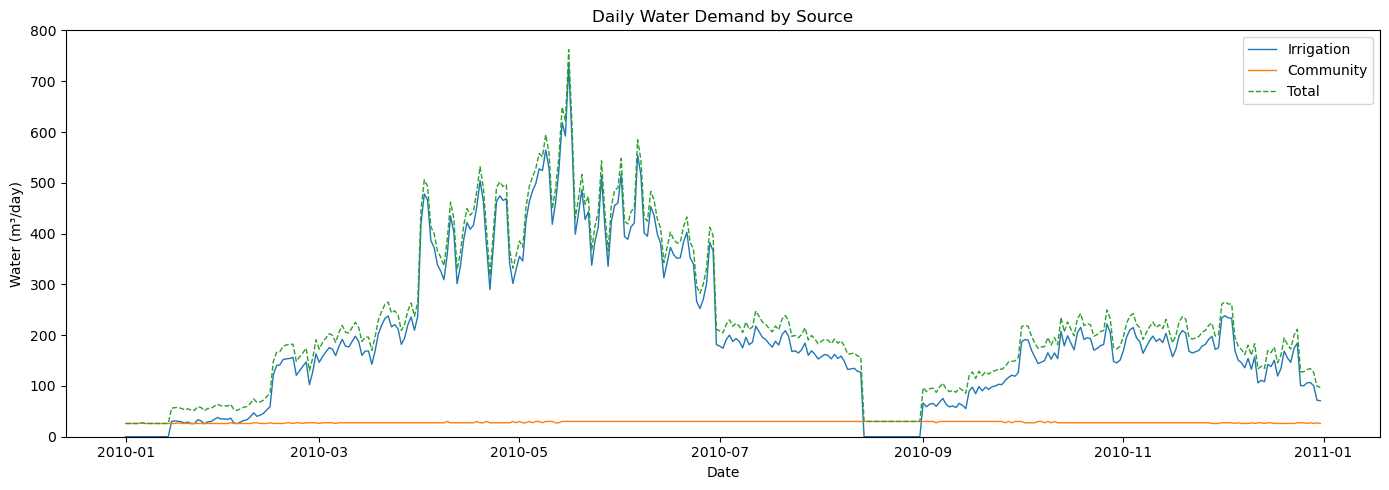

In [3]:
# Daily water demand by source (line plot)
from src.plots import plot_water_demand_by_source

fig = plot_water_demand_by_source(df, years=YEARS)
plt.show()

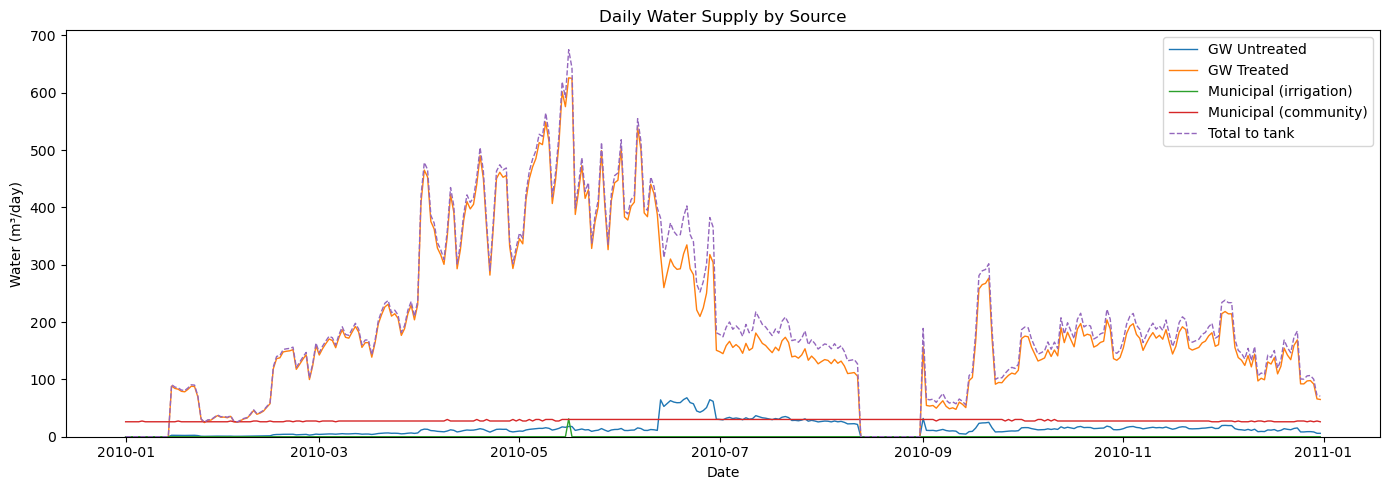

In [4]:
# Daily water supply by source (line plot)
from src.plots import plot_water_supply_by_source

fig = plot_water_supply_by_source(df, years=YEARS)
plt.show()

/Users/dpbirge/GITHUB/community-agri-pv/src/plots.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


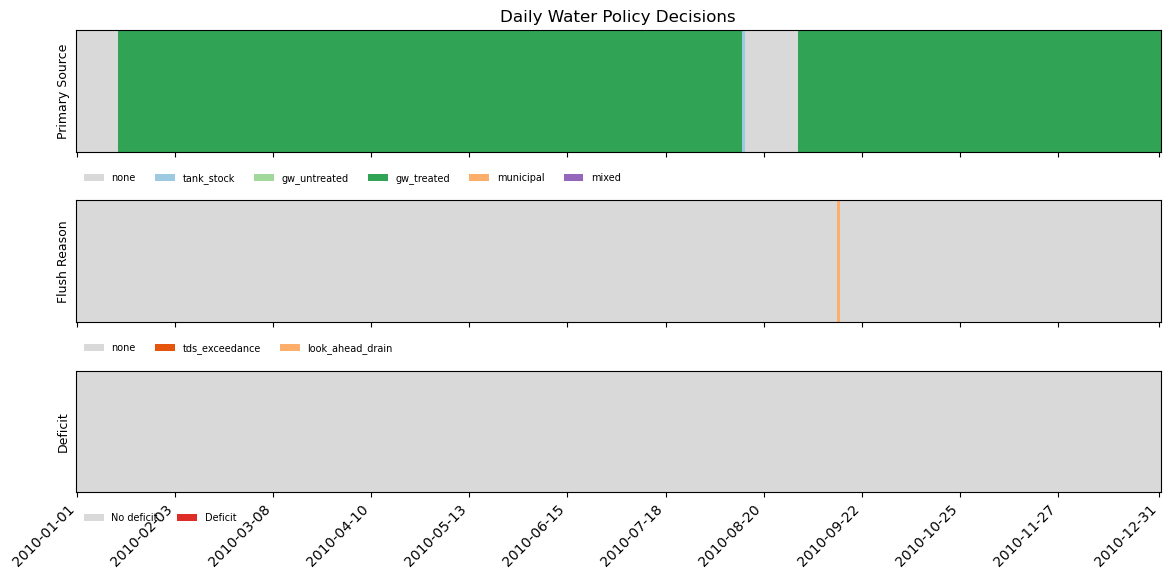

In [5]:
# Policy decisions heatmap (primary source, flush reason, deficit per day)
from src.plots import plot_water_policy_heatmap

fig = plot_water_policy_heatmap(df, years=YEARS)
plt.show()

In [ ]:
# Summary: policy metadata breakdown
import pandas as pd

if YEARS is not None:
    start_year = df['day'].dt.year.min()
    sub = df[df['day'].dt.year < start_year + YEARS]
else:
    sub = df

if 'policy_primary_source' in sub.columns:
    print("Primary source (days):")
    print(sub['policy_primary_source'].value_counts().to_string())
if 'policy_tds_action' in sub.columns:
    print("\nTDS action (days):")
    print(sub['policy_tds_action'].value_counts().replace('', 'none').to_string())
if 'policy_deficit' in sub.columns:
    print(f"\nDeficit days: {sub['policy_deficit'].sum()} / {len(sub)}")
if 'policy_strategy' in sub.columns:
    print(f"Strategy: {sub['policy_strategy'].iloc[0]}")